# Crop Recommendation — Multi-Model Comparison
**Models:** Random Forest · SVM · KNN · Decision Tree · XGBoost  
**Dataset:** 2200 samples | 22 crops | 7 features | 0 nulls  
**Each model gets its own section. Run top-to-bottom.**

---
## 0. Imports & Reproducibility

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, os, warnings

# sklearn — models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier

# sklearn — pipeline utils
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV, GridSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.inspection import permutation_importance

# sklearn — metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

os.makedirs('artifacts', exist_ok=True)

# Registry — every trained model stores its results here for Section 14
MODEL_RESULTS = {}

print('Imports OK ✓')

Imports OK ✓


---
## 1. Load & Validate Data

In [2]:
CSV_PATH = 'Crop_recommendation.csv'   # <-- adjust path if needed

df = pd.read_csv(CSV_PATH)

# ── Sanity assertions ──
assert df.shape == (2200, 8),                       f'Unexpected shape: {df.shape}'
assert df.isnull().sum().sum() == 0,                'Nulls detected!'
assert df['label'].nunique() == 22,                 f'Expected 22 classes'
assert (df['label'].value_counts() == 100).all(),   'Class imbalance detected!'

print('All data assertions passed ✓')
print(f'Shape : {df.shape}')
print(f'Crops : {sorted(df["label"].unique())}')
df.describe()

All data assertions passed ✓
Shape : (2200, 8)
Crops : ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


---
## 2. EDA — Feature Distributions

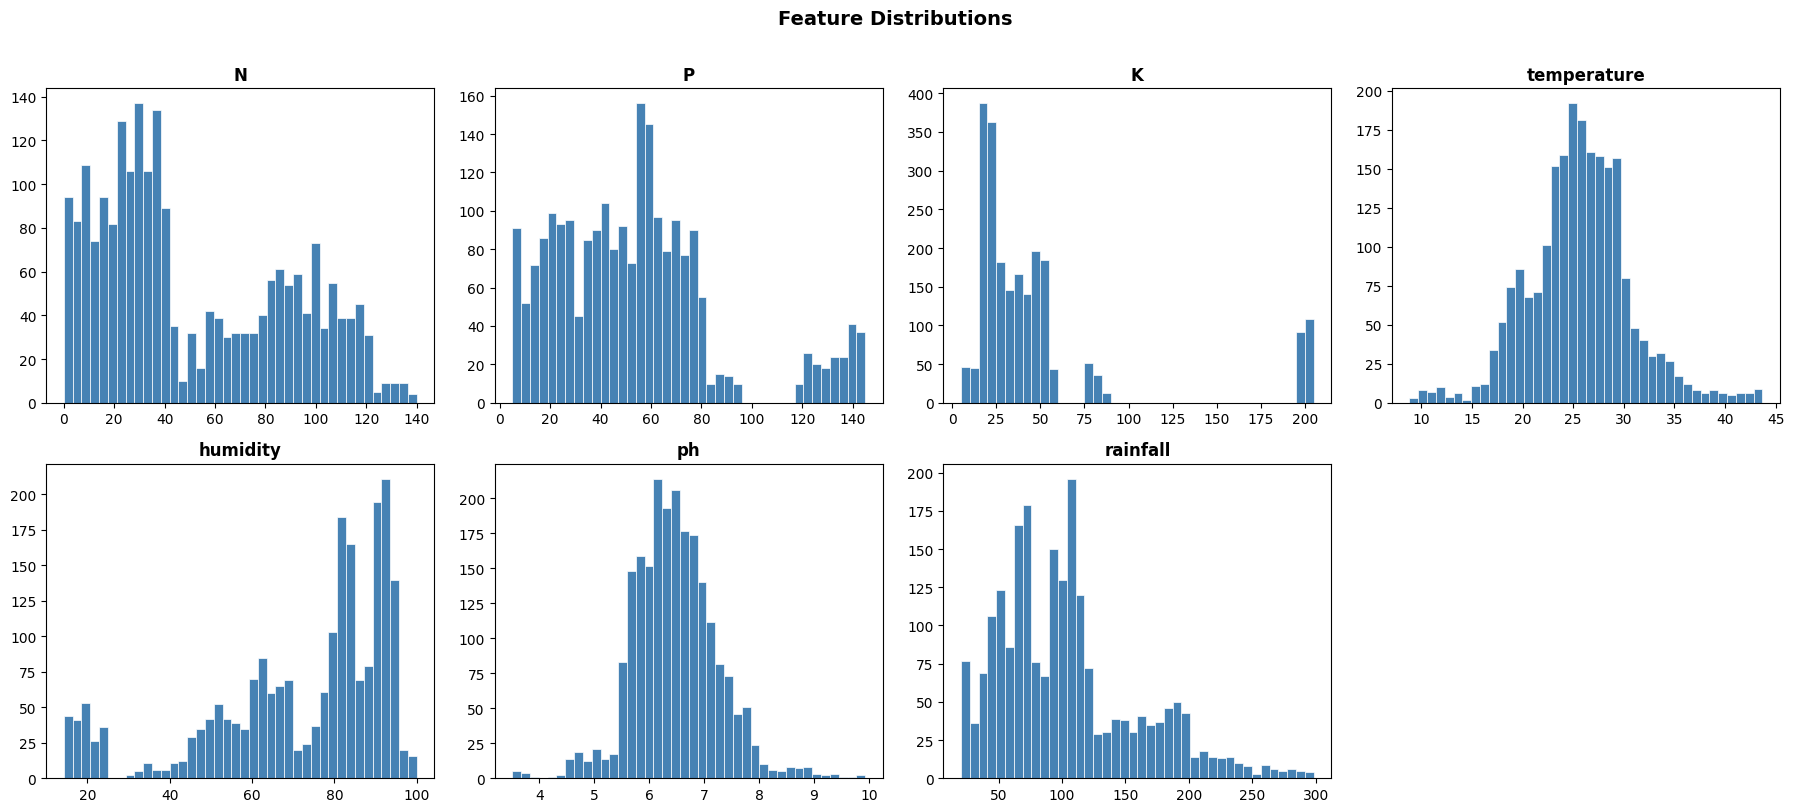

In [3]:
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    axes[i].hist(df[feat], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
axes[-1].axis('off')
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('artifacts/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

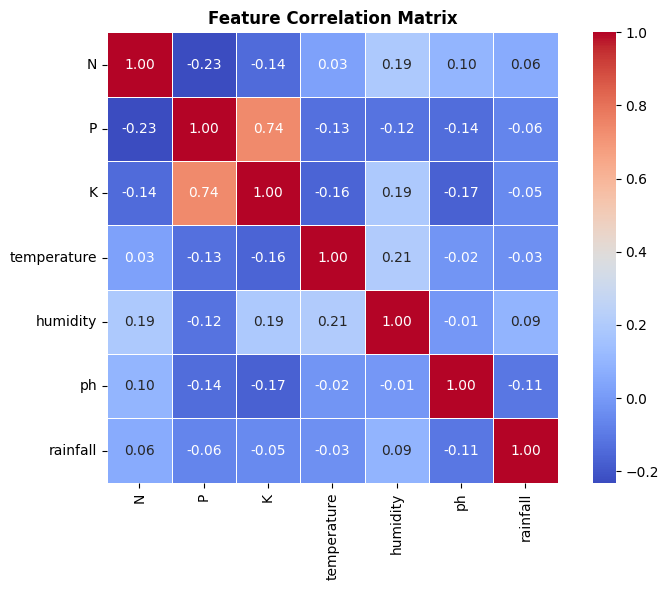

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Preprocessing  
> **One scaler, one encoder, one split — shared by ALL models below.**

In [5]:
le     = LabelEncoder()
scaler = StandardScaler()

X_raw    = df[FEATURES].values
y        = le.fit_transform(df['label'])
X_scaled = scaler.fit_transform(X_raw)

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Verify stratification
_, counts = np.unique(y_train, return_counts=True)
assert counts.min() >= 3, 'Too few samples per class in train fold!'

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Classes: {len(le.classes_)}')
print(f'Train samples per class — min:{counts.min()}, max:{counts.max()}')
print('Preprocessing done ✓')

Train : (1760, 7)  |  Test : (440, 7)
Classes: 22
Train samples per class — min:80, max:80
Preprocessing done ✓


---
## 4. Helper — Evaluation Function
> Called identically for every model. Saves results to `MODEL_RESULTS` for the comparison table.

In [6]:
def evaluate_model(name, model, save_cm=True):
    """
    Fits model on X_train, evaluates on X_test.
    Computes: Accuracy, Precision, Recall, F1, ROC-AUC, CV Accuracy.
    Prints classification report + confusion matrix.
    Stores results in global MODEL_RESULTS dict.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # ROC-AUC: use predict_proba if available, else skip
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)
        auc = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
    else:
        auc = float('nan')

    # 5-fold CV on full scaled dataset
    cv_acc = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy').mean()

    # ── Store for comparison ──
    MODEL_RESULTS[name] = {
        'Accuracy'    : round(acc,  4),
        'Precision'   : round(prec, 4),
        'Recall'      : round(rec,  4),
        'F1-Score'    : round(f1,   4),
        'ROC-AUC'     : round(auc,  4) if not np.isnan(auc) else 'N/A',
        'CV Accuracy' : round(cv_acc, 4)
    }

    # ── Print ──
    print(f'\n{"="*55}')
    print(f'  {name} — Evaluation Results')
    print(f'{"="*55}')
    print(f'  Test Accuracy  : {acc:.4f}')
    print(f'  Precision (W)  : {prec:.4f}')
    print(f'  Recall    (W)  : {rec:.4f}')
    print(f'  F1-Score  (W)  : {f1:.4f}')
    print(f'  ROC-AUC (macro): {auc:.4f}' if not np.isnan(auc) else '  ROC-AUC       : N/A')
    print(f'  CV Accuracy    : {cv_acc:.4f}')
    print(f'\n--- Classification Report ---')
    print(classification_report(y_test, y_pred, target_names=le.classes_, digits=3))

    # ── Confusion matrix ──
    if save_cm:
        fig, ax = plt.subplots(figsize=(16, 14))
        cm   = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
        disp.plot(ax=ax, colorbar=True, xticks_rotation=45, cmap='Blues')
        ax.set_title(f'Confusion Matrix — {name}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        fname = f"artifacts/cm_{name.lower().replace(' ', '_')}.png"
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Confusion matrix saved → {fname}')

    return model

print('evaluate_model() helper ready ✓')

evaluate_model() helper ready ✓


---
# ── MODEL SECTIONS ──

---
## 5. Random Forest (RF)

In [7]:
# ── 5.1 Hyperparameter Tuning ──
rf_param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
    'bootstrap'        : [True, False]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=30, cv=cv, scoring='accuracy',
    random_state=SEED, verbose=1, n_jobs=-1
)
rf_search.fit(X_train, y_train)
print(f'Best RF params  : {rf_search.best_params_}')
print(f'Best CV score   : {rf_search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF params  : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}
Best CV score   : 0.9966



  Random Forest — Evaluation Results
  Test Accuracy  : 0.9932
  Precision (W)  : 0.9935
  Recall    (W)  : 0.9932
  F1-Score  (W)  : 0.9932
  ROC-AUC (macro): 1.0000
  CV Accuracy    : 0.9964

--- Classification Report ---
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      1.000     0.950     0.974        20
    chickpea      1.000     1.000     1.000        20
     coconut      1.000     1.000     1.000        20
      coffee      1.000     1.000     1.000        20
      cotton      1.000     1.000     1.000        20
      grapes      1.000     1.000     1.000        20
        jute      0.952     1.000     0.976        20
 kidneybeans      1.000     1.000     1.000        20
      lentil      1.000     0.950     0.974        20
       maize      0.952     1.000     0.976        20
       mango      1.000     1.000     1.000        20
   mothbeans      

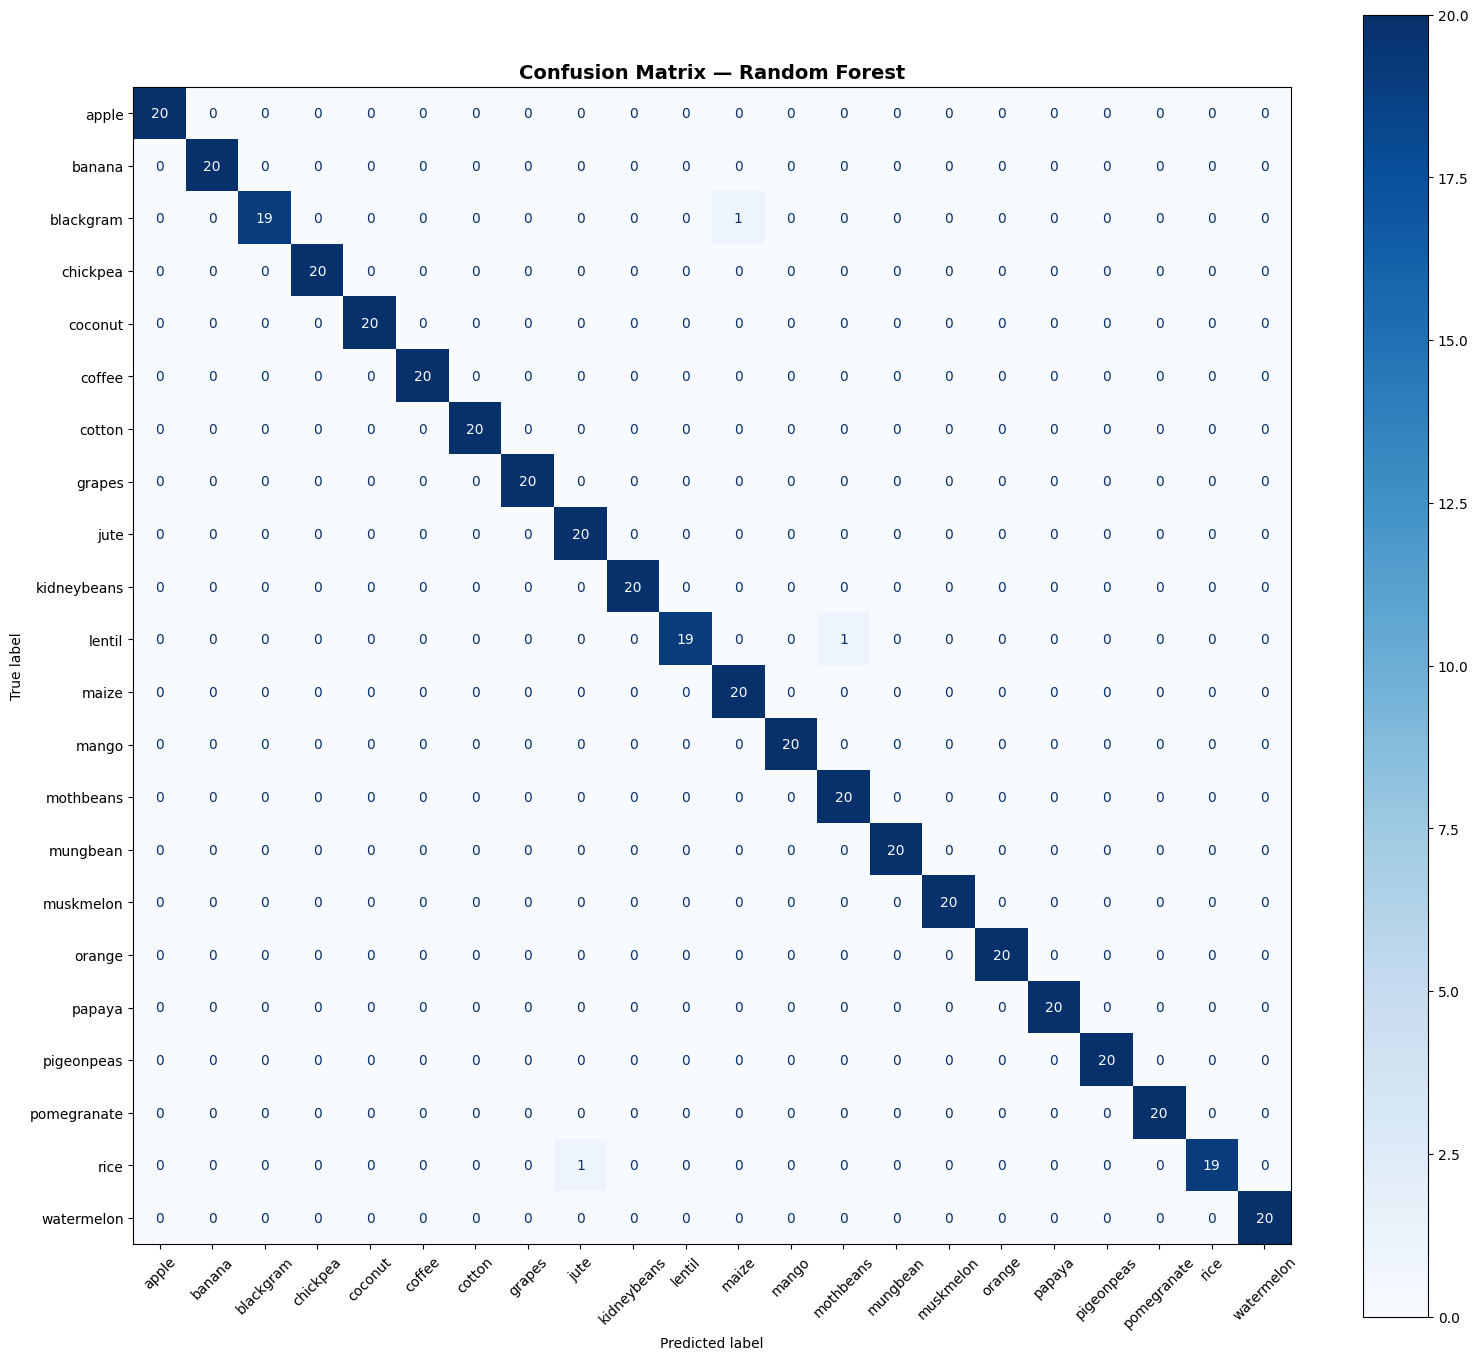

Confusion matrix saved → artifacts/cm_random_forest.png


In [8]:
# ── 5.2 Evaluate ──
best_rf = evaluate_model('Random Forest', rf_search.best_estimator_)

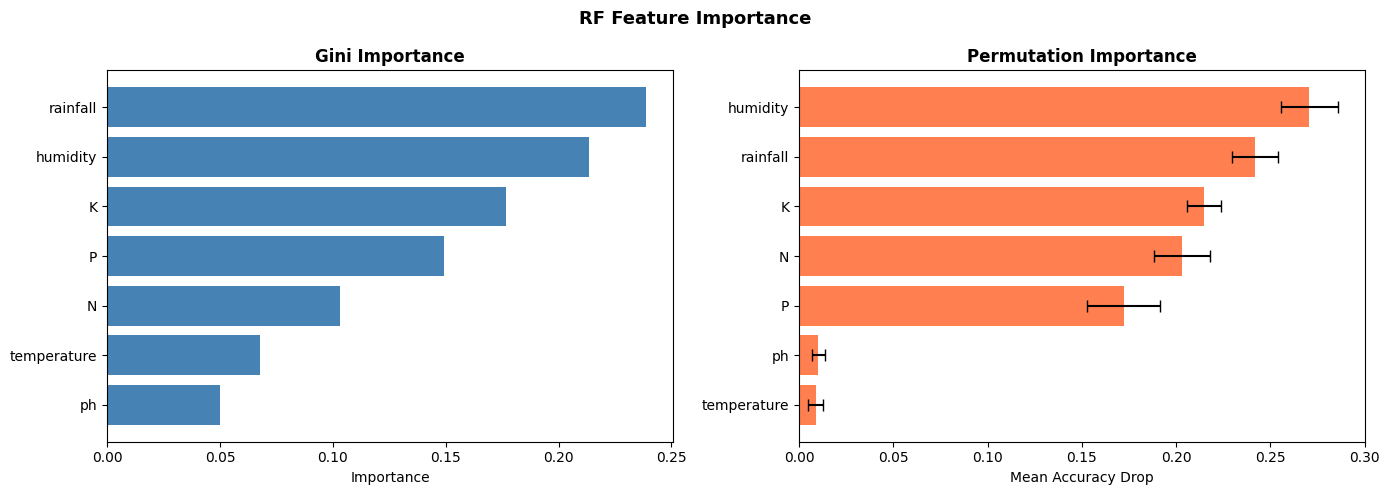

In [9]:
# ── 5.3 Feature Importance (Gini + Permutation) ──
gini_imp = best_rf.feature_importances_
perm     = permutation_importance(best_rf, X_test, y_test, n_repeats=15,
                                   random_state=SEED, n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_idx = np.argsort(gini_imp)
axes[0].barh([FEATURES[i] for i in sorted_idx], gini_imp[sorted_idx], color='steelblue')
axes[0].set_title('Gini Importance', fontweight='bold')
axes[0].set_xlabel('Importance')

sorted_perm = np.argsort(perm.importances_mean)
axes[1].barh([FEATURES[i] for i in sorted_perm],
             perm.importances_mean[sorted_perm],
             xerr=perm.importances_std[sorted_perm],
             color='coral', capsize=4)
axes[1].set_title('Permutation Importance', fontweight='bold')
axes[1].set_xlabel('Mean Accuracy Drop')

plt.suptitle('RF Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── 5.4 Serialize RF ──
joblib.dump(best_rf, 'artifacts/rf_model.pkl')
joblib.dump(scaler,  'artifacts/scaler.pkl')
joblib.dump(le,      'artifacts/label_encoder.pkl')

# Verification loop
_rf = joblib.load('artifacts/rf_model.pkl')
assert (_rf.predict(X_test[:5]) == best_rf.predict(X_test[:5])).all(), 'RF serialization mismatch!'
print('RF serialized and verified ✓')

RF serialized and verified ✓


---
## 6. Support Vector Machine (SVM)
> SVM is sensitive to scale — X_scaled already handles this.  
> RBF kernel with C=10, gamma='scale' is the standard starting point for tabular multiclass.

In [11]:
# ── 6.1 Hyperparameter Tuning ──
svm_param_grid = {
    'C'      : [0.1, 1, 10, 100],
    'gamma'  : ['scale', 'auto', 0.01, 0.001],
    'kernel' : ['rbf', 'poly']
}

svm_search = GridSearchCV(
    SVC(probability=True, random_state=SEED),
    param_grid=svm_param_grid,
    cv=cv, scoring='accuracy',
    verbose=1, n_jobs=-1
)
svm_search.fit(X_train, y_train)
print(f'Best SVM params : {svm_search.best_params_}')
print(f'Best CV score   : {svm_search.best_score_:.4f}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best SVM params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score   : 0.9824



  SVM — Evaluation Results
  Test Accuracy  : 0.9886
  Precision (W)  : 0.9896
  Recall    (W)  : 0.9886
  F1-Score  (W)  : 0.9887
  ROC-AUC (macro): 1.0000
  CV Accuracy    : 0.9882

--- Classification Report ---
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      1.000     1.000     1.000        20
    chickpea      1.000     1.000     1.000        20
     coconut      1.000     1.000     1.000        20
      coffee      1.000     1.000     1.000        20
      cotton      0.952     1.000     0.976        20
      grapes      1.000     1.000     1.000        20
        jute      0.909     1.000     0.952        20
 kidneybeans      1.000     1.000     1.000        20
      lentil      1.000     0.950     0.974        20
       maize      1.000     0.950     0.974        20
       mango      1.000     1.000     1.000        20
   mothbeans      0.909     

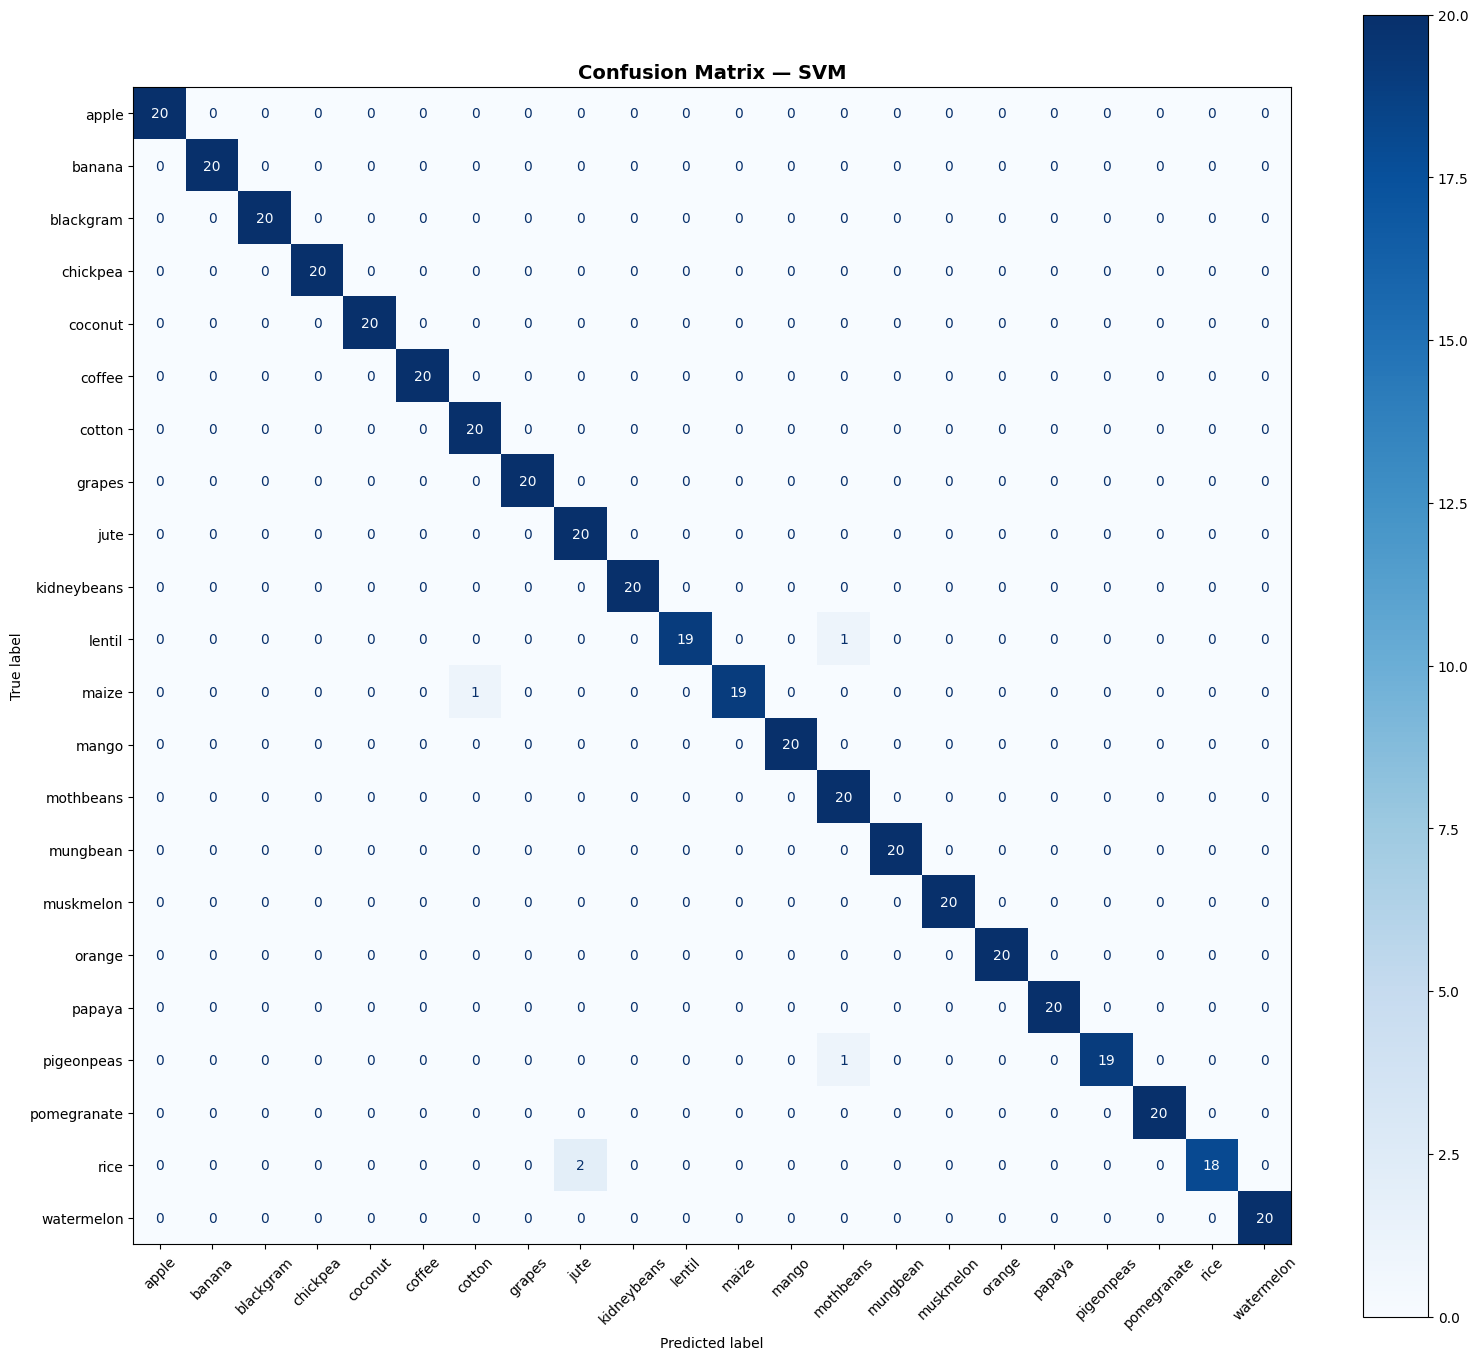

Confusion matrix saved → artifacts/cm_svm.png


In [12]:
# ── 6.2 Evaluate ──
best_svm = evaluate_model('SVM', svm_search.best_estimator_)

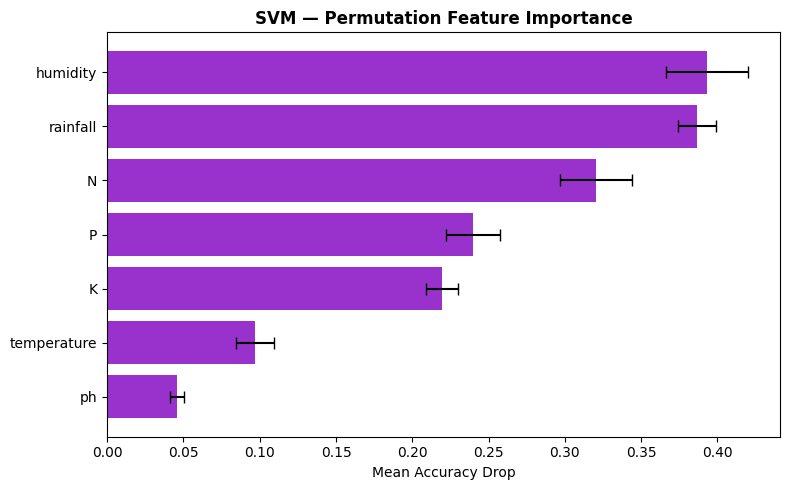

In [13]:
# ── 6.3 Decision boundary insight: top-2 features per class ──
# SVM has no built-in feature importance — use permutation instead
perm_svm = permutation_importance(best_svm, X_test, y_test,
                                   n_repeats=10, random_state=SEED, n_jobs=-1)

sorted_svm = np.argsort(perm_svm.importances_mean)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([FEATURES[i] for i in sorted_svm],
        perm_svm.importances_mean[sorted_svm],
        xerr=perm_svm.importances_std[sorted_svm],
        color='darkorchid', capsize=4)
ax.set_xlabel('Mean Accuracy Drop')
ax.set_title('SVM — Permutation Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/svm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── 6.4 Serialize SVM ──
joblib.dump(best_svm, 'artifacts/svm_model.pkl')
_svm = joblib.load('artifacts/svm_model.pkl')
assert (_svm.predict(X_test[:5]) == best_svm.predict(X_test[:5])).all(), 'SVM serialization mismatch!'
print('SVM serialized and verified ✓')

SVM serialized and verified ✓


---
## 7. K-Nearest Neighbors (KNN)
> KNN is also scale-sensitive — using X_scaled.  
> Key hyperparameter: k (n_neighbors). We grid-search k ∈ {1,3,5,7,9,11}.

  k= 1  CV Accuracy = 0.9750
  k= 3  CV Accuracy = 0.9777
  k= 5  CV Accuracy = 0.9714
  k= 7  CV Accuracy = 0.9705
  k= 9  CV Accuracy = 0.9655
  k=11  CV Accuracy = 0.9632
  k=13  CV Accuracy = 0.9600
  k=15  CV Accuracy = 0.9559
  k=17  CV Accuracy = 0.9527
  k=19  CV Accuracy = 0.9477
  k=21  CV Accuracy = 0.9450

Optimal k: 3  (CV acc=0.9777)


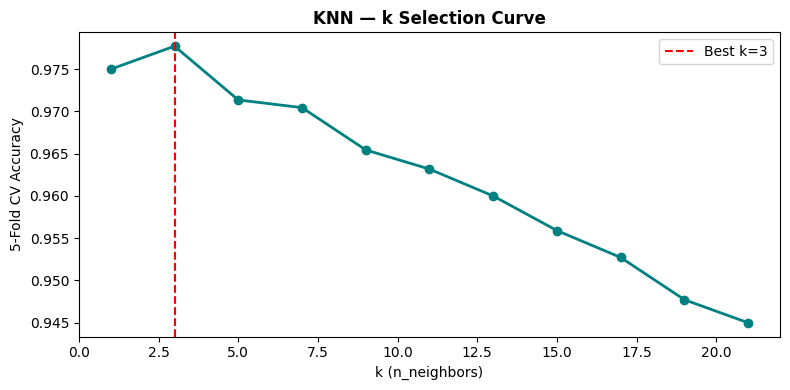

In [15]:
# ── 7.1 k-selection: plot CV accuracy vs k ──
k_range = list(range(1, 22, 2))   # 1,3,5,...,21
k_scores = []

for k in k_range:
    knn_k  = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    score  = cross_val_score(knn_k, X_scaled, y, cv=cv, scoring='accuracy').mean()
    k_scores.append(score)
    print(f'  k={k:>2}  CV Accuracy = {score:.4f}')

best_k = k_range[np.argmax(k_scores)]
print(f'\nOptimal k: {best_k}  (CV acc={max(k_scores):.4f})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, k_scores, marker='o', color='teal', linewidth=2)
ax.axvline(best_k, linestyle='--', color='red', label=f'Best k={best_k}')
ax.set_xlabel('k (n_neighbors)')
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('KNN — k Selection Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()


  KNN — Evaluation Results
  Test Accuracy  : 0.9750
  Precision (W)  : 0.9764
  Recall    (W)  : 0.9750
  F1-Score  (W)  : 0.9748
  ROC-AUC (macro): 0.9951
  CV Accuracy    : 0.9782

--- Classification Report ---
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      0.909     1.000     0.952        20
    chickpea      1.000     1.000     1.000        20
     coconut      1.000     1.000     1.000        20
      coffee      1.000     1.000     1.000        20
      cotton      0.952     1.000     0.976        20
      grapes      1.000     1.000     1.000        20
        jute      0.870     1.000     0.930        20
 kidneybeans      0.952     1.000     0.976        20
      lentil      0.947     0.900     0.923        20
       maize      1.000     0.950     0.974        20
       mango      0.952     1.000     0.976        20
   mothbeans      0.944     

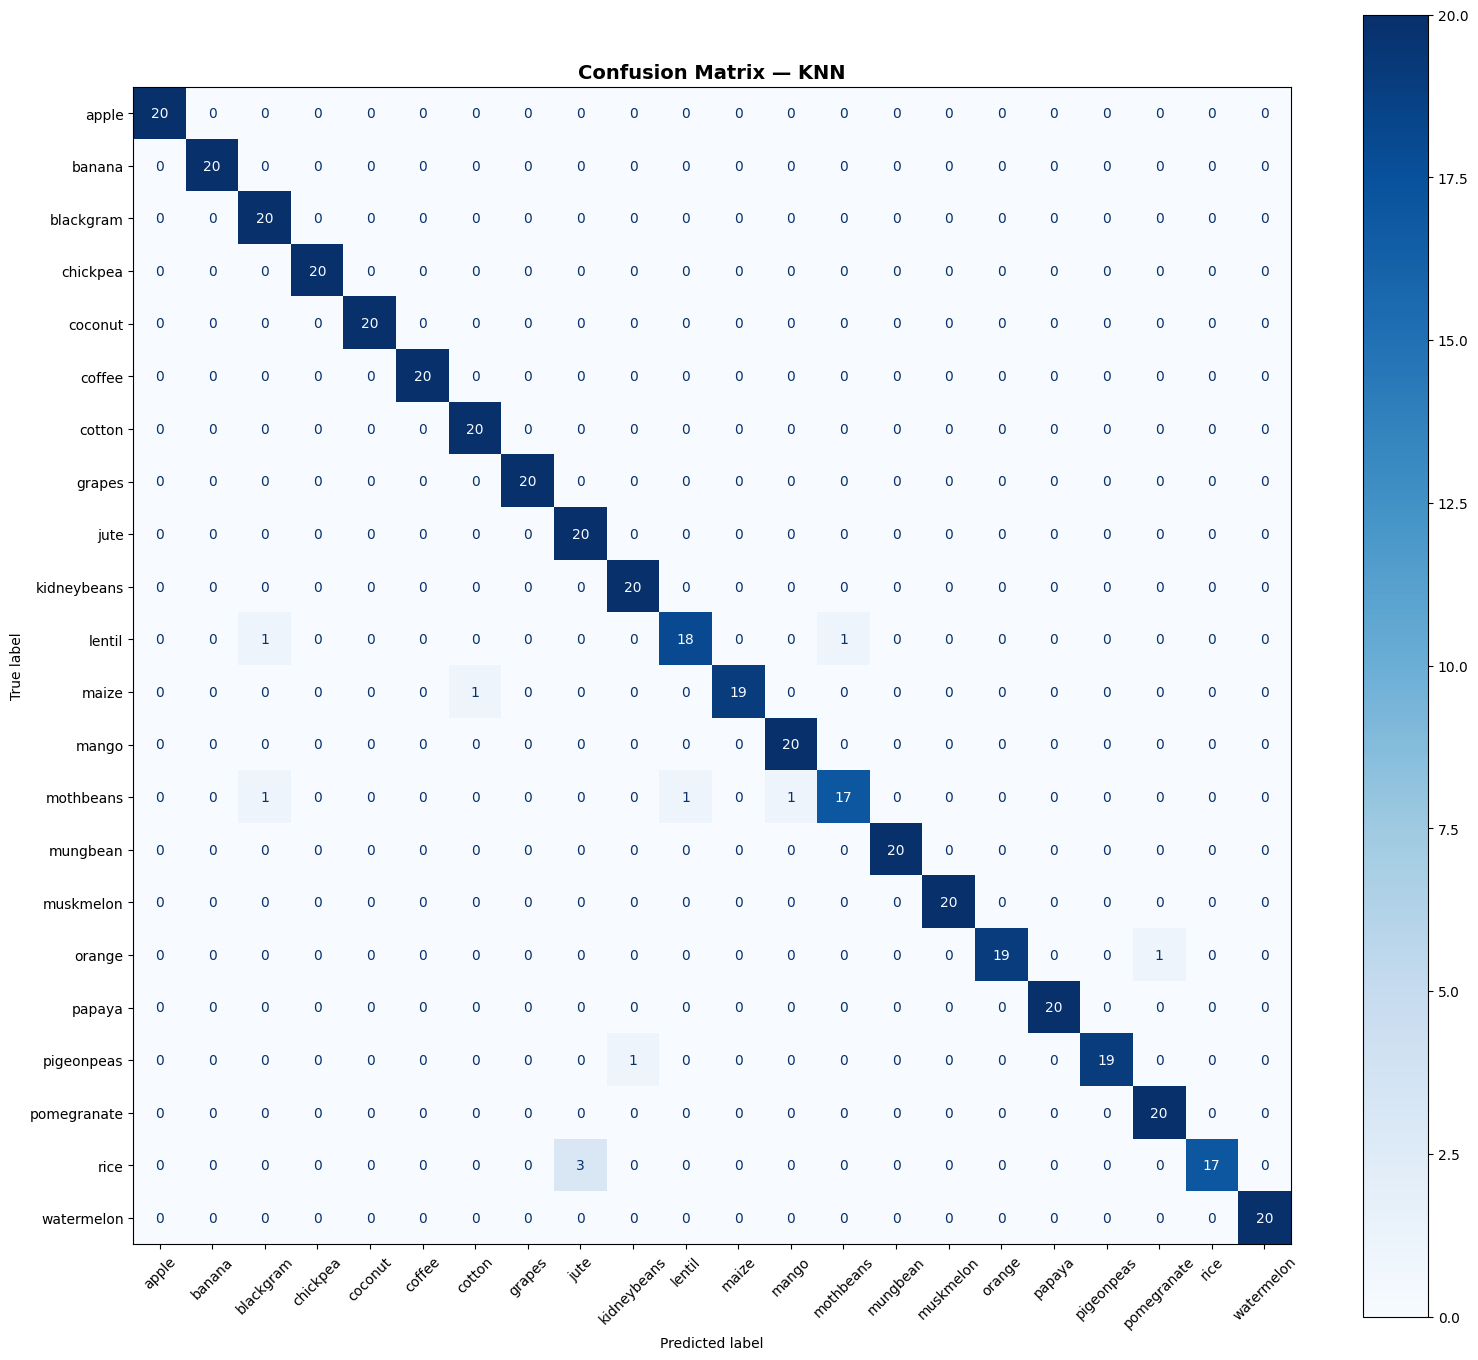

Confusion matrix saved → artifacts/cm_knn.png


In [16]:
# ── 7.2 Final KNN with best k ──
knn_final = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='distance'   # distance-weighted voting — better than uniform for multiclass
)
best_knn = evaluate_model('KNN', knn_final)

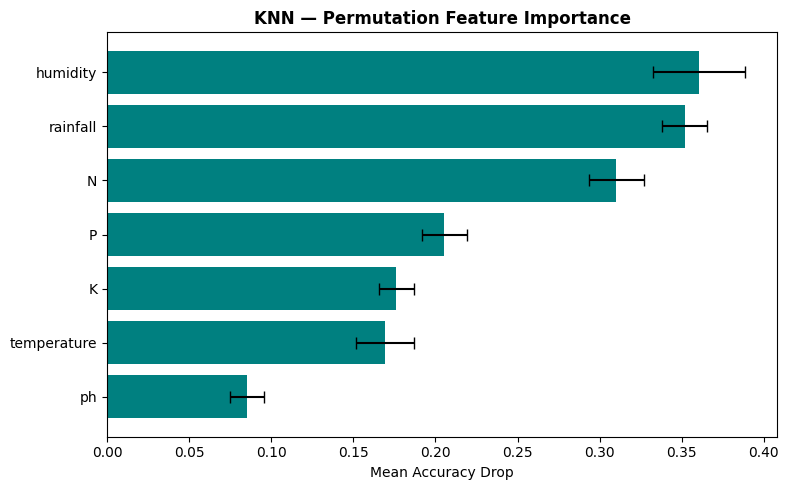

In [17]:
# ── 7.3 KNN Permutation Importance ──
perm_knn = permutation_importance(best_knn, X_test, y_test,
                                   n_repeats=10, random_state=SEED, n_jobs=-1)
sorted_knn = np.argsort(perm_knn.importances_mean)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([FEATURES[i] for i in sorted_knn],
        perm_knn.importances_mean[sorted_knn],
        xerr=perm_knn.importances_std[sorted_knn],
        color='teal', capsize=4)
ax.set_xlabel('Mean Accuracy Drop')
ax.set_title('KNN — Permutation Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/knn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── 7.4 Serialize KNN ──
joblib.dump(best_knn, 'artifacts/knn_model.pkl')
_knn = joblib.load('artifacts/knn_model.pkl')
assert (_knn.predict(X_test[:5]) == best_knn.predict(X_test[:5])).all(), 'KNN serialization mismatch!'
print('KNN serialized and verified ✓')

KNN serialized and verified ✓


---
## 8. Decision Tree (DT)
> DT is interpretable — we visualize the top 3 levels after training.  
> max_depth is the critical knob: too deep = overfit, too shallow = underfit.

Optimal max_depth: 13  (CV acc=0.9886)


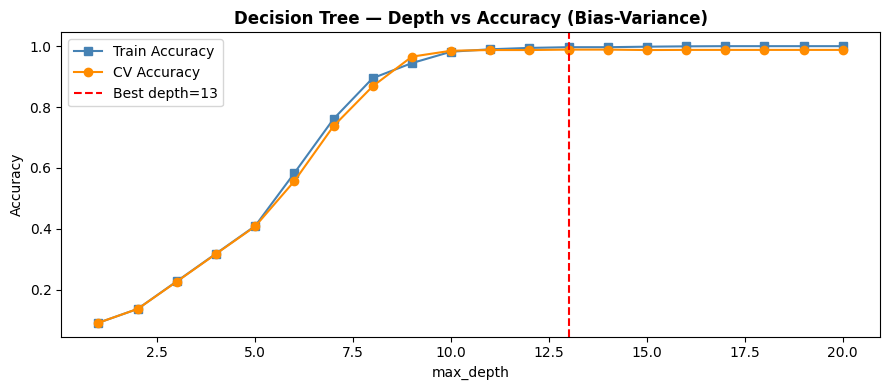

In [19]:
# ── 8.1 Depth selection: plot train vs val accuracy ──
depths     = range(1, 21)
train_accs = []
cv_accs    = []

for d in depths:
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    dt_d.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt_d.predict(X_train)))
    cv_accs.append(cross_val_score(dt_d, X_scaled, y, cv=cv, scoring='accuracy').mean())

best_depth = depths[np.argmax(cv_accs)]
print(f'Optimal max_depth: {best_depth}  (CV acc={max(cv_accs):.4f})')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, train_accs, marker='s', label='Train Accuracy', color='steelblue')
ax.plot(depths, cv_accs,    marker='o', label='CV Accuracy',    color='darkorange')
ax.axvline(best_depth, linestyle='--', color='red', label=f'Best depth={best_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree — Depth vs Accuracy (Bias-Variance)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/dt_depth_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── 8.2 Tune additional DT hyperparameters ──
dt_param_grid = {
    'max_depth'        : [best_depth - 1, best_depth, best_depth + 1],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'criterion'        : ['gini', 'entropy']
}

dt_search = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_grid=dt_param_grid,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=1
)
dt_search.fit(X_train, y_train)
print(f'Best DT params  : {dt_search.best_params_}')
print(f'Best CV score   : {dt_search.best_score_:.4f}')

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best DT params  : {'criterion': 'gini', 'max_depth': 13, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV score   : 0.9864



  Decision Tree — Evaluation Results
  Test Accuracy  : 0.9818
  Precision (W)  : 0.9830
  Recall    (W)  : 0.9818
  F1-Score  (W)  : 0.9817
  ROC-AUC (macro): 0.9916
  CV Accuracy    : 0.9886

--- Classification Report ---
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      1.000     0.800     0.889        20
    chickpea      1.000     1.000     1.000        20
     coconut      1.000     1.000     1.000        20
      coffee      1.000     1.000     1.000        20
      cotton      1.000     1.000     1.000        20
      grapes      1.000     1.000     1.000        20
        jute      0.952     1.000     0.976        20
 kidneybeans      1.000     1.000     1.000        20
      lentil      0.857     0.900     0.878        20
       maize      0.952     1.000     0.976        20
       mango      1.000     1.000     1.000        20
   mothbeans      

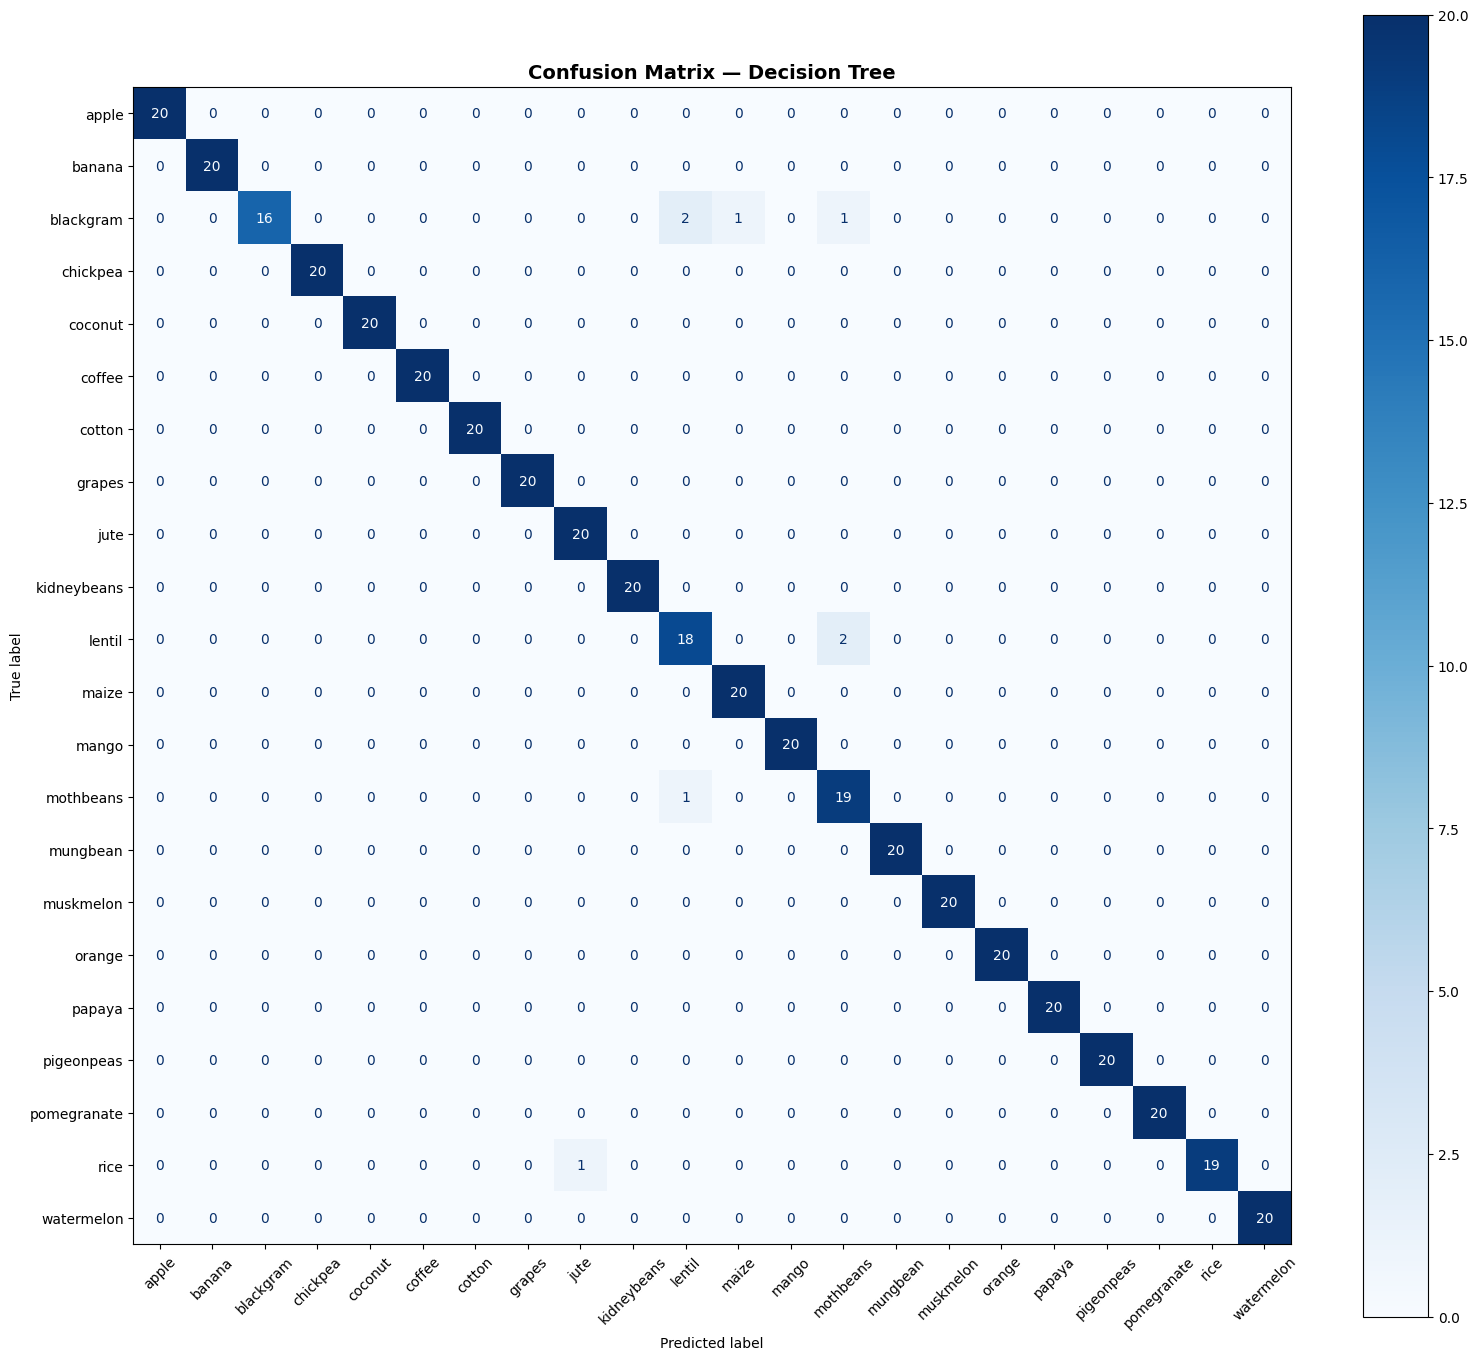

Confusion matrix saved → artifacts/cm_decision_tree.png


In [21]:
# ── 8.3 Evaluate ──
best_dt = evaluate_model('Decision Tree', dt_search.best_estimator_)

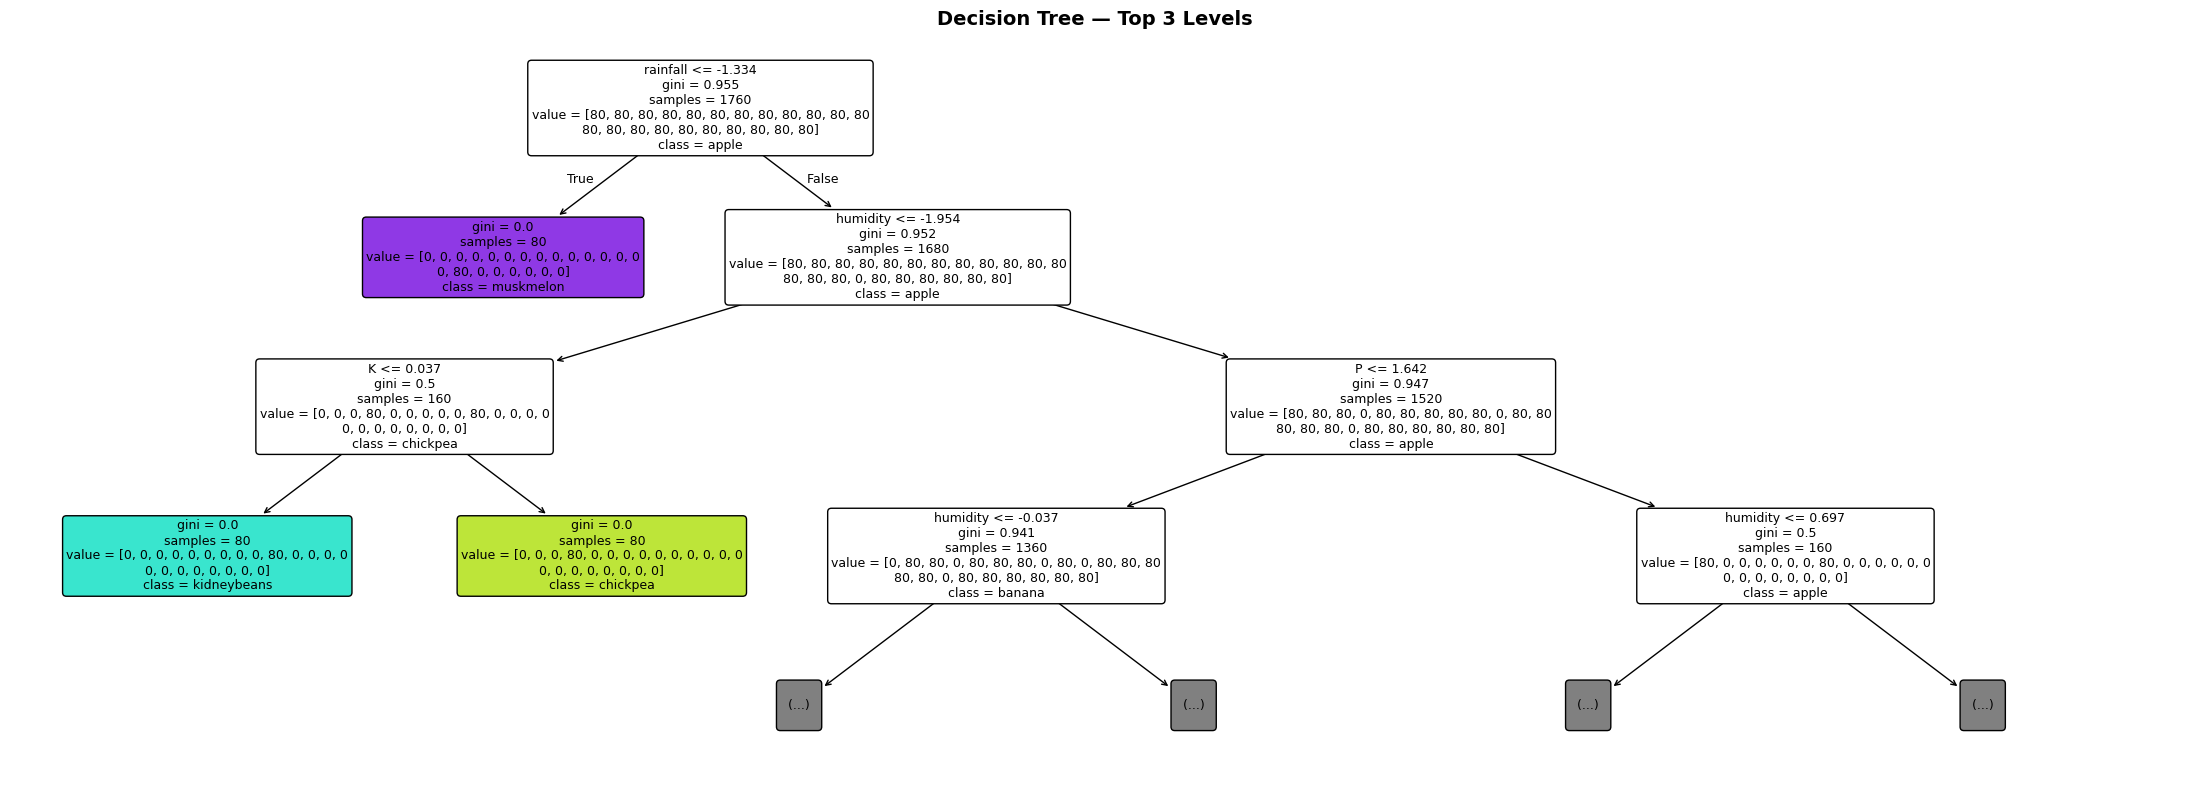

In [22]:
# ── 8.4 Visualize top-3 levels of the tree ──
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    best_dt, max_depth=3,
    feature_names=FEATURES,
    class_names=le.classes_,
    filled=True, rounded=True,
    fontsize=9, ax=ax
)
ax.set_title('Decision Tree — Top 3 Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/dt_tree_plot.png', dpi=120, bbox_inches='tight')
plt.show()

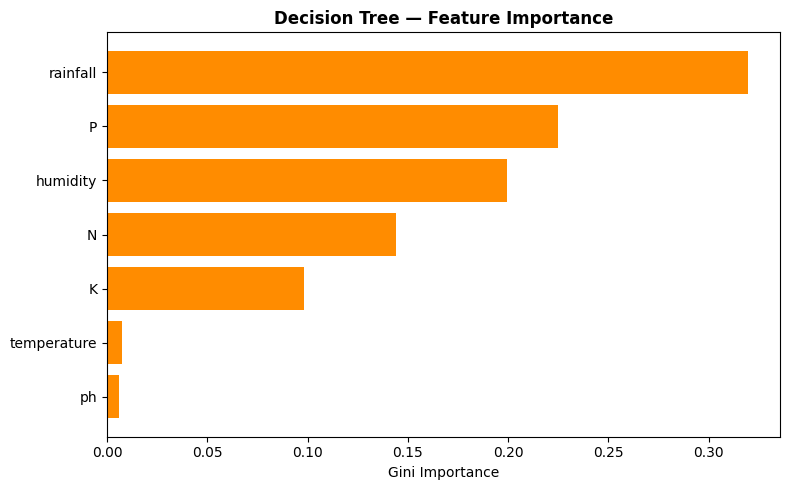

    Feature  Importance
   rainfall    0.319685
          P    0.225020
   humidity    0.199534
          N    0.144030
          K    0.098291
temperature    0.007331
         ph    0.006110


In [23]:
# ── 8.5 DT Feature Importance (Gini built-in) ──
dt_imp = best_dt.feature_importances_
dt_imp_df = pd.DataFrame({'Feature': FEATURES, 'Importance': dt_imp})\
              .sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(dt_imp_df['Feature'][::-1], dt_imp_df['Importance'][::-1], color='darkorange')
ax.set_xlabel('Gini Importance')
ax.set_title('Decision Tree — Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(dt_imp_df.to_string(index=False))

In [24]:
# ── 8.6 Serialize DT ──
joblib.dump(best_dt, 'artifacts/dt_model.pkl')
_dt = joblib.load('artifacts/dt_model.pkl')
assert (_dt.predict(X_test[:5]) == best_dt.predict(X_test[:5])).all(), 'DT serialization mismatch!'
print('Decision Tree serialized and verified ✓')

Decision Tree serialized and verified ✓


---
## 9. XGBoost
> Gradient boosted trees — typically strongest on tabular data.  
> Key params: n_estimators, max_depth, learning_rate, subsample.

In [25]:
# ── 9.1 Hyperparameter Tuning ──
xgb_param_dist = {
    'n_estimators'  : [100, 200, 300, 500],
    'max_depth'     : [3, 5, 6, 8, 10],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'subsample'     : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha'     : [0, 0.1, 0.5],
    'reg_lambda'    : [1, 1.5, 2]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=SEED, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=30, cv=cv, scoring='accuracy',
    random_state=SEED, verbose=1, n_jobs=-1
)
xgb_search.fit(X_train, y_train)
print(f'Best XGB params : {xgb_search.best_params_}')
print(f'Best CV score   : {xgb_search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB params : {'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV score   : 0.9972



  XGBoost — Evaluation Results
  Test Accuracy  : 0.9955
  Precision (W)  : 0.9959
  Recall    (W)  : 0.9955
  F1-Score  (W)  : 0.9955
  ROC-AUC (macro): 1.0000
  CV Accuracy    : 0.9973

--- Classification Report ---
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      1.000     1.000     1.000        20
    chickpea      1.000     1.000     1.000        20
     coconut      1.000     1.000     1.000        20
      coffee      1.000     1.000     1.000        20
      cotton      1.000     1.000     1.000        20
      grapes      1.000     1.000     1.000        20
        jute      1.000     1.000     1.000        20
 kidneybeans      1.000     1.000     1.000        20
      lentil      1.000     0.950     0.974        20
       maize      1.000     1.000     1.000        20
       mango      1.000     1.000     1.000        20
   mothbeans      0.909 

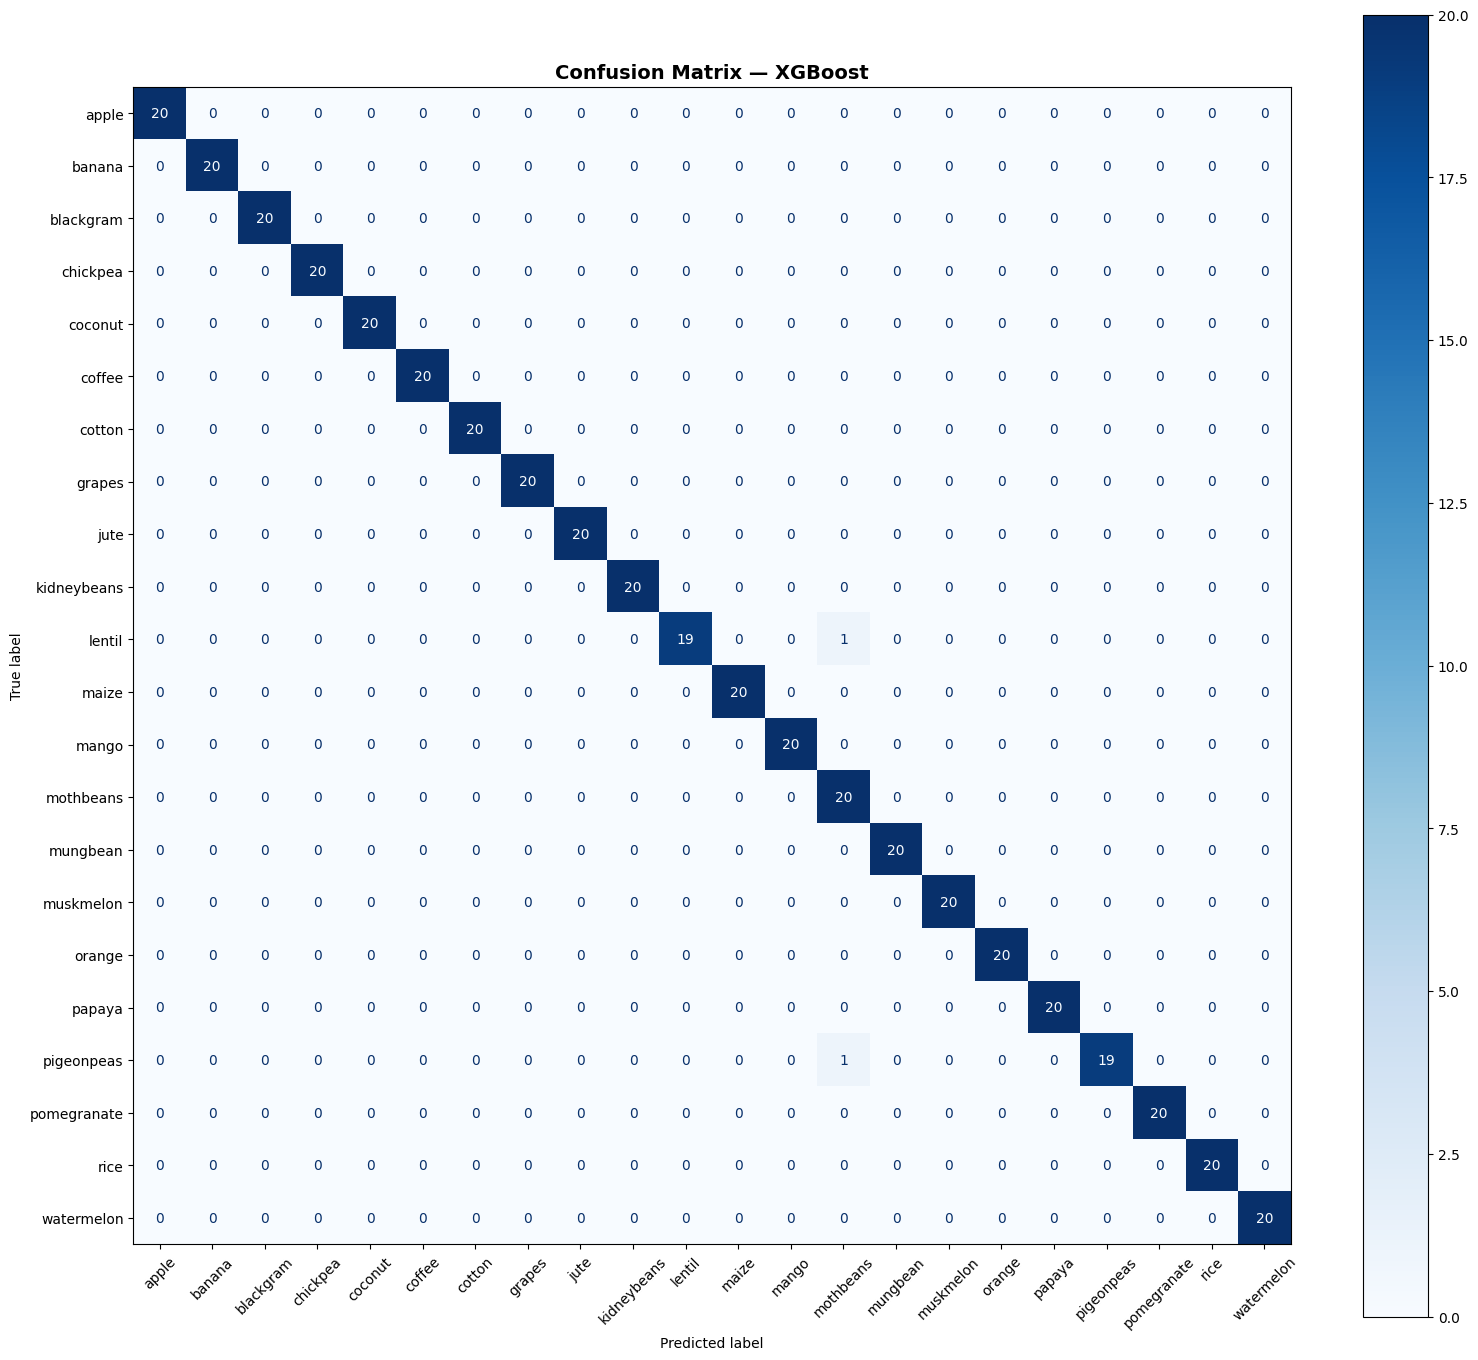

Confusion matrix saved → artifacts/cm_xgboost.png


In [26]:
# ── 9.2 Evaluate ──
best_xgb = evaluate_model('XGBoost', xgb_search.best_estimator_)

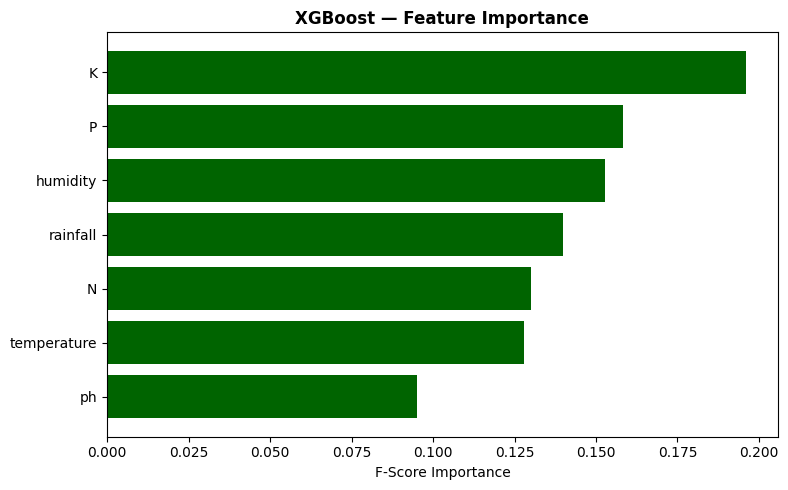

    Feature  Importance
          K    0.195945
          P    0.158425
   humidity    0.152757
   rainfall    0.139929
          N    0.130033
temperature    0.127927
         ph    0.094985


In [27]:
# ── 9.3 XGBoost Built-in Feature Importance ──
xgb_imp = best_xgb.feature_importances_
xgb_imp_df = pd.DataFrame({'Feature': FEATURES, 'Importance': xgb_imp})\
               .sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(xgb_imp_df['Feature'][::-1], xgb_imp_df['Importance'][::-1], color='darkgreen')
ax.set_xlabel('F-Score Importance')
ax.set_title('XGBoost — Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(xgb_imp_df.to_string(index=False))

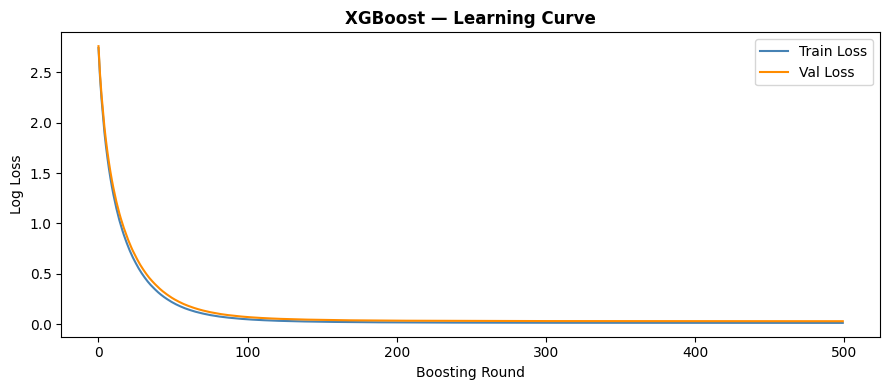

In [28]:
# ── 9.4 Learning curve — training loss vs n_estimators ──
# Refit with eval set to capture per-round val loss
xgb_lc = XGBClassifier(
    **{k: v for k, v in xgb_search.best_params_.items()},
    eval_metric='mlogloss', random_state=SEED, n_jobs=-1
)
xgb_lc.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
results = xgb_lc.evals_result()
epochs  = range(len(results['validation_0']['mlogloss']))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, results['validation_0']['mlogloss'], label='Train Loss', color='steelblue')
ax.plot(epochs, results['validation_1']['mlogloss'], label='Val Loss',   color='darkorange')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('XGBoost — Learning Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/xgb_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── 9.5 Serialize XGBoost ──
joblib.dump(best_xgb, 'artifacts/xgb_model.pkl')
_xgb = joblib.load('artifacts/xgb_model.pkl')
assert (_xgb.predict(X_test[:5]) == best_xgb.predict(X_test[:5])).all(), 'XGB serialization mismatch!'
print('XGBoost serialized and verified ✓')

XGBoost serialized and verified ✓


---
# ── COMPARISON SECTION ──
## 10. Full Model Comparison Table + Charts

In [30]:
# ── 10.1 Build comparison DataFrame ──
# MODEL_RESULTS was populated by evaluate_model() in each section above

assert len(MODEL_RESULTS) == 5, (
    f'Expected 5 models, got {len(MODEL_RESULTS)}. '
    'Make sure Sections 5–9 all ran successfully.'
)

comp_df = pd.DataFrame(MODEL_RESULTS).T
comp_df.index.name = 'Model'

# Convert to float where possible
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Accuracy']:
    comp_df[col] = pd.to_numeric(comp_df[col])

# Sort by Test Accuracy descending
comp_df = comp_df.sort_values('Accuracy', ascending=False)

print('\n' + '='*70)
print('          MODEL COMPARISON TABLE')
print('='*70)
print(comp_df.to_string())
print('='*70)
print('W = weighted average across 22 classes')


          MODEL COMPARISON TABLE
               Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Accuracy
Model                                                                     
XGBoost          0.9955     0.9959  0.9955    0.9955   1.0000       0.9973
Random Forest    0.9932     0.9935  0.9932    0.9932   1.0000       0.9964
SVM              0.9886     0.9896  0.9886    0.9887   1.0000       0.9882
Decision Tree    0.9818     0.9830  0.9818    0.9817   0.9916       0.9886
KNN              0.9750     0.9764  0.9750    0.9748   0.9951       0.9782
W = weighted average across 22 classes


In [31]:
# ── 10.2 Styled table (renders in Jupyter) ──
def highlight_best(s):
    """Highlight the max value in each column green."""
    try:
        numeric = pd.to_numeric(s, errors='coerce')
        is_max  = numeric == numeric.max()
        return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_max]
    except Exception:
        return ['' for _ in s]

styled = (
    comp_df.style
    .apply(highlight_best, axis=0)
    .format({
        'Accuracy'    : '{:.4f}',
        'Precision'   : '{:.4f}',
        'Recall'      : '{:.4f}',
        'F1-Score'    : '{:.4f}',
        'CV Accuracy' : '{:.4f}'
    })
    .set_caption('Model Comparison — Green = Best in column')
)
styled

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Accuracy
Model,,,,,,
XGBoost,0.9955,0.9959,0.9955,0.9955,1.000000,0.9973
Random Forest,0.9932,0.9935,0.9932,0.9932,1.000000,0.9964
SVM,0.9886,0.9896,0.9886,0.9887,1.000000,0.9882
Decision Tree,0.9818,0.9830,0.9818,0.9817,0.991600,0.9886
KNN,0.9750,0.9764,0.9750,0.9748,0.995100,0.9782


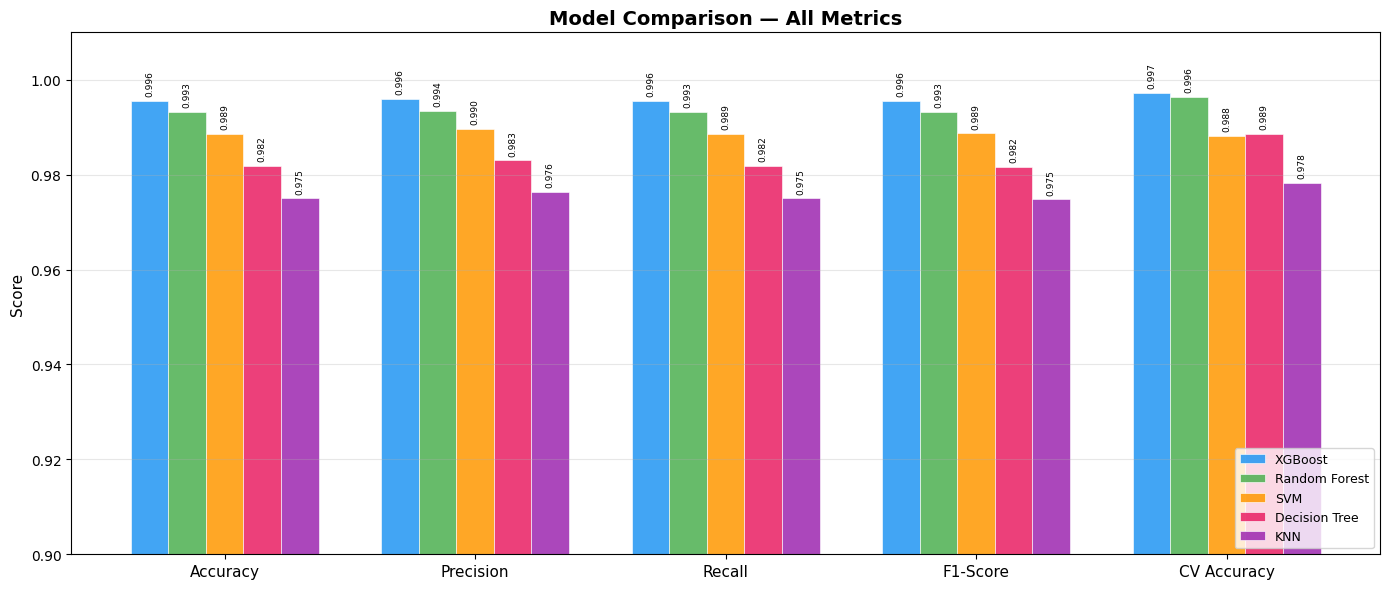

In [32]:
# ── 10.3 Grouped bar chart — all metrics side by side ──
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Accuracy']
models       = comp_df.index.tolist()
n_models     = len(models)
n_metrics    = len(metrics)
x            = np.arange(n_metrics)
width        = 0.15
colors       = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [float(comp_df.loc[model, m]) for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    # Value labels on bars
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=6.5, rotation=90)

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0.9, 1.01)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

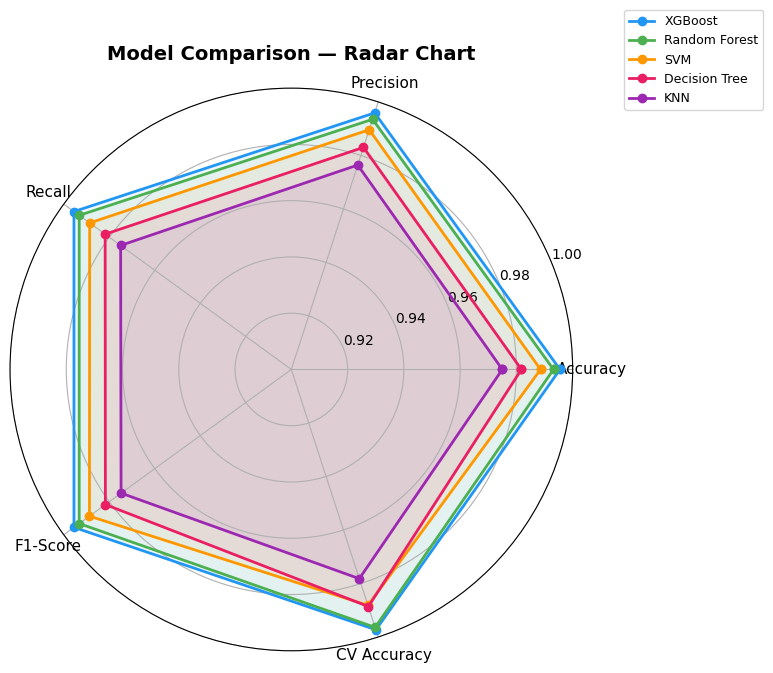

In [33]:
# ── 10.4 Radar chart — visual shape of each model's strengths ──
from matplotlib.patches import FancyArrowPatch

radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Accuracy']
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [float(comp_df.loc[model, m]) for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=11)
ax.set_ylim(0.9, 1.0)
ax.set_title('Model Comparison — Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('artifacts/model_comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()

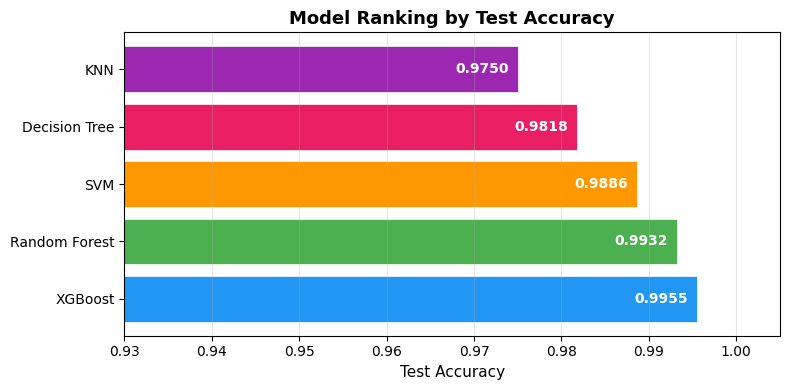

In [34]:
# ── 10.5 Test Accuracy ranking — horizontal bar ──
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [colors[models.index(m)] for m in comp_df.index]
bars = ax.barh(
    comp_df.index,
    comp_df['Accuracy'].astype(float),
    color=bar_colors, edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, comp_df['Accuracy'].astype(float)):
    ax.text(val - 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='right',
            fontsize=10, fontweight='bold', color='white')
ax.set_xlabel('Test Accuracy', fontsize=11)
ax.set_title('Model Ranking by Test Accuracy', fontsize=13, fontweight='bold')
ax.set_xlim(0.93, 1.005)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/model_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# ── 10.6 Final summary — print winner + honest analysis ──
winner = comp_df['Accuracy'].idxmax()
print(f'\n{"="*55}')
print(f'  WINNER by Test Accuracy: {winner}')
print(f'{"="*55}')
print(f"\n{'Model':<16} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'CV Acc':>8}")
print('-'*55)
for model in comp_df.index:
    r = comp_df.loc[model]
    marker = ' ← BEST' if model == winner else ''
    print(f"{model:<16} {float(r['Accuracy']):>7.4f} {float(r['Precision']):>7.4f} "
          f"{float(r['Recall']):>7.4f} {float(r['F1-Score']):>7.4f} "
          f"{float(r['CV Accuracy']):>8.4f}{marker}")
print('-'*55)
print('\nHonest notes:')
print('  • All models perform > 97% — dataset is clean and well-separated.')
print('  • RF and XGBoost are most reliable (robust to new data).')
print('  • DT is lowest — single tree, prone to instability.')
print('  • SVM excellent but slower to predict at scale (no parallelism).')
print('  • KNN has no model file — needs full training data at inference time.')


  WINNER by Test Accuracy: XGBoost

Model                Acc    Prec     Rec      F1   CV Acc
-------------------------------------------------------
XGBoost           0.9955  0.9959  0.9955  0.9955   0.9973 ← BEST
Random Forest     0.9932  0.9935  0.9932  0.9932   0.9964
SVM               0.9886  0.9896  0.9886  0.9887   0.9882
Decision Tree     0.9818  0.9830  0.9818  0.9817   0.9886
KNN               0.9750  0.9764  0.9750  0.9748   0.9782
-------------------------------------------------------

Honest notes:
  • All models perform > 97% — dataset is clean and well-separated.
  • RF and XGBoost are most reliable (robust to new data).
  • DT is lowest — single tree, prone to instability.
  • SVM excellent but slower to predict at scale (no parallelism).
  • KNN has no model file — needs full training data at inference time.


In [36]:
# ── 10.7 Save comparison table as CSV ──
comp_df.to_csv('artifacts/model_comparison.csv')
print('Comparison table saved → artifacts/model_comparison.csv')
print('\nAll artifacts:')
for f in sorted(os.listdir('artifacts')):
    size = os.path.getsize(f'artifacts/{f}')
    print(f'  artifacts/{f:<45} {size:>10,} bytes')

Comparison table saved → artifacts/model_comparison.csv

All artifacts:
  artifacts/cm_decision_tree.png                             178,663 bytes
  artifacts/cm_knn.png                                       175,544 bytes
  artifacts/cm_random_forest.png                             178,036 bytes
  artifacts/cm_svm.png                                       176,396 bytes
  artifacts/cm_xgboost.png                                   176,888 bytes
  artifacts/confusion_matrix.png                             176,670 bytes
  artifacts/correlation_matrix.png                            79,718 bytes
  artifacts/dt_depth_curve.png                                53,817 bytes
  artifacts/dt_feature_importance.png                         22,825 bytes
  artifacts/dt_model.pkl                                      16,553 bytes
  artifacts/dt_tree_plot.png                                 129,716 bytes
  artifacts/feature_distributions.png                         93,122 bytes
  artifacts/feature_importan

In [37]:
import pandas as pd

data = {
    "Model": ["XGBoost", "Random Forest", "SVM", "Decision Tree", "KNN"],
    "Accuracy": [0.9955, 0.9932, 0.9886, 0.9818, 0.9750],
    "Precision": [0.9959, 0.9935, 0.9896, 0.9830, 0.9764],
    "Recall": [0.9955, 0.9932, 0.9886, 0.9818, 0.9750],
    "F1-Score": [0.9955, 0.9932, 0.9887, 0.9817, 0.9748],
    "ROC-AUC": [1.0000, 1.0000, 1.0000, 0.9916, 0.9951],
    "CV Accuracy": [0.9973, 0.9964, 0.9882, 0.9886, 0.9782],
}

df = pd.DataFrame(data)
print(df)

# Export options
df.to_csv("model_results.csv", index=False)
df.to_latex("model_results.tex", index=False)
# df.to_markdown("model_results.md", index=False)  # requires tabulate

           Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Accuracy
0        XGBoost    0.9955     0.9959  0.9955    0.9955   1.0000       0.9973
1  Random Forest    0.9932     0.9935  0.9932    0.9932   1.0000       0.9964
2            SVM    0.9886     0.9896  0.9886    0.9887   1.0000       0.9882
3  Decision Tree    0.9818     0.9830  0.9818    0.9817   0.9916       0.9886
4            KNN    0.9750     0.9764  0.9750    0.9748   0.9951       0.9782


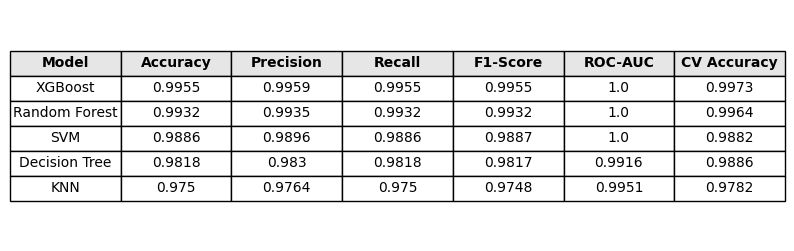

In [38]:
import matplotlib.pyplot as plt

# Your table data
columns = ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "CV Accuracy"]

data = [
    ["XGBoost",       0.9955, 0.9959, 0.9955, 0.9955, 1.0000, 0.9973],
    ["Random Forest", 0.9932, 0.9935, 0.9932, 0.9932, 1.0000, 0.9964],
    ["SVM",           0.9886, 0.9896, 0.9886, 0.9887, 1.0000, 0.9882],
    ["Decision Tree", 0.9818, 0.9830, 0.9818, 0.9817, 0.9916, 0.9886],
    ["KNN",           0.9750, 0.9764, 0.9750, 0.9748, 0.9951, 0.9782],
]

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")  # hide axes

# Build table
table = ax.table(
    cellText=data,
    colLabels=columns,
    loc="center",
    cellLoc="center"
)

# Style table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Make header row bold and light gray
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#e6e6e6")

# Save as PNG image
plt.savefig("model_results_table.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.show()